# Confidence Intervals by Bootstrapping Approach
## and its Application in Stock Market

---

**Department of Data Science & Analytics**  
**Central University of Rajasthan**

| Field | Details |
|---|---|
| **Names** |  Yash Verma, Kunal Goyal |
| **Course** | Advanced Statistical Methods and Stochastic Process |
| **Course Code** | 6.0MBD10 |
| **Instructor** | Dr. Vidyottama Jain |
| **Session** | 2025–26 |

---

## 1. Problem Statement / Objective

In stock market analysis, two of the most important quantities we care about are:
- **Mean Return**: The average daily profit or loss from holding a stock.
- **Volatility**: How much the returns fluctuate (a measure of risk).

Classical statistics gives us a single-point estimate (e.g., "average return = 0.05%"), but that estimate always comes with uncertainty — especially with financial data, which is noisy and non-normal. **Confidence Intervals (CIs)** give us a range of plausible values for the true parameter.

Traditional CI methods (like the t-interval) assume the data is normally distributed. Financial returns often violate this assumption — they have fat tails and skewness. **The Bootstrap method** is a resampling technique that builds CIs without making strong distributional assumptions.

**Goal of this project:** Apply five different bootstrap CI methods to the NIFTY 50 index and compare them with the classical CI. We then use these CIs for practical risk estimation, Sharpe Ratio analysis, and simple trading insights.

## 2. Data Understanding

We use **NIFTY 50 index data for the last 5 years** (approximately April 2021 – April 2026). The dataset contains daily OHLCV (Open, High, Low, Close, Volume) data downloaded from Yahoo Finance.

In [4]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

# Create outputs folder
os.makedirs('outputs', exist_ok=True)

print("All libraries loaded successfully!")
print("Outputs will be saved in: outputs/")

All libraries loaded successfully!
Outputs will be saved in: outputs/


In [5]:
# Load the dataset
# The CSV has a two-row header from Yahoo Finance, so we parse accordingly
raw = pd.read_csv(r'C:\Users\vyash\Downloads\VJ\CIA 2\Data Set\nifty50_5years.csv', header=[0, 1])
raw.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Remove the extra header row that says 'Date'
df_raw = raw[raw['Date'] != 'Date'].reset_index(drop=True)

print("First 5 rows of the dataset:")
df_raw.head()

First 5 rows of the dataset:


,Date,Close,High,Low,Open,Volume
0,2021-04-27,14653.049805,14667.549805,14484.849609,14493.799805,451800.0
1,2021-04-28,14864.549805,14890.250000,14694.950195,14710.500000,457000.0
2,2021-04-29,14894.900391,15044.349609,14814.450195,14979.000000,517500.0
3,2021-04-30,14631.099609,14855.450195,14601.700195,14747.349609,613900.0
4,2021-05-03,14634.150391,14673.849609,14416.250000,14481.049805,448900.0


In [6]:
# Dataset info
print("Dataset Info:")
print("-" * 40)
df_raw.info()

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1236 non-null   str    
 1   Close   1236 non-null   float64
 2   High    1236 non-null   float64
 3   Low     1236 non-null   float64
 4   Open    1236 non-null   float64
 5   Volume  1236 non-null   float64
dtypes: float64(5), str(1)
memory usage: 58.1 KB


In [7]:
# Basic statistics (after converting types)
df_desc = df_raw.copy()
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df_desc[col] = pd.to_numeric(df_desc[col])

print("Descriptive Statistics:")
df_desc.describe().round(2)

Descriptive Statistics:


,Close,High,Low,Open,Volume
count,1236.00,1236.00,1236.00,1236.00,1236.00
mean,20667.66,20766.42,20562.43,20675.15,306926.54
std,3481.03,3492.68,3473.44,3481.77,106009.43
min,14496.50,14637.90,14416.25,14481.05,0.00
25%,17576.71,17660.87,17466.15,17583.86,241250.00
50%,19737.95,19812.72,19668.97,19755.12,282450.00
75%,24275.19,24366.15,24141.09,24299.15,354650.00
max,26328.55,26373.20,26210.05,26333.70,1006100.00


**Column Descriptions:**
- **Date**: Trading date (business days only)
- **Open**: Index value at the start of the trading session
- **High**: Highest value reached during the day
- **Low**: Lowest value reached during the day
- **Close**: Index value at end of trading session (most important for analysis)
- **Volume**: Total number of shares traded

We will primarily use the **Close** price to compute daily returns.

## 3. Data Preprocessing

Before analysis, we need to:
1. Convert the Date column to proper datetime format
2. Sort data by date (ascending)
3. Convert numeric columns from string to float
4. Check for and handle any missing values

In [8]:
# Make a working copy and convert types
df = df_raw.copy()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert all price/volume columns to numeric
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort by date ascending
df = df.sort_values('Date').reset_index(drop=True)

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print()

# Drop rows with missing Close price (if any)
df.dropna(subset=['Close'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total trading days: {len(df)}")

Missing values in each column:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Dataset shape after cleaning: (1236, 6)
Date range: 2021-04-27 to 2026-04-27
Total trading days: 1236


In [9]:
# Confirm clean dataset
print("First 3 rows after preprocessing:")
print(df.head(3).to_string())
print()
print("Last 3 rows:")
print(df.tail(3).to_string())

First 3 rows after preprocessing:
        Date         Close          High           Low          Open    Volume
0 2021-04-27  14653.049805  14667.549805  14484.849609  14493.799805  451800.0
1 2021-04-28  14864.549805  14890.250000  14694.950195  14710.500000  457000.0
2 2021-04-29  14894.900391  15044.349609  14814.450195  14979.000000  517500.0

Last 3 rows:
           Date         Close          High           Low          Open    Volume
1233 2026-04-23  24173.050781  24310.199219  24134.800781  24202.349609  467500.0
1234 2026-04-24  23897.949219  24206.000000  23813.650391  24100.550781  438400.0
1235 2026-04-27  24092.699219  24130.699219  23936.199219  23945.449219       0.0


## 4. Feature Engineering

We compute two key features from the raw price data:

**Log Returns:**  
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred over simple returns because they are additive across time and better behaved statistically.

**Annualised Volatility:**  
$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$

252 is the number of trading days in a year.

In [10]:
# Compute log returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop the first row (NaN return)
df.dropna(subset=['Log_Return'], inplace=True)
df.reset_index(drop=True, inplace=True)

# The returns array we will use for all analysis
returns = df['Log_Return'].values

# Basic return stats
mean_return = np.mean(returns)
daily_vol   = np.std(returns, ddof=1)
annual_vol  = daily_vol * np.sqrt(252)

print("Feature Engineering Complete")
print("=" * 40)
print(f"Number of return observations : {len(returns)}")
print(f"Mean daily log return         : {mean_return:.6f} ({mean_return*100:.4f}%)")
print(f"Daily volatility (std dev)    : {daily_vol:.6f}")
print(f"Annualised volatility         : {annual_vol:.4f} ({annual_vol*100:.2f}%)")
print(f"Skewness                      : {stats.skew(returns):.4f}")
print(f"Excess Kurtosis               : {stats.kurtosis(returns):.4f}")

Feature Engineering Complete
Number of return observations : 1235
Mean daily log return         : 0.000403 (0.0403%)
Daily volatility (std dev)    : 0.008693
Annualised volatility         : 0.1380 (13.80%)
Skewness                      : -0.4700
Excess Kurtosis               : 4.0388


In [11]:
# Show the dataframe with new features
print("Dataset with computed features:")
df[['Date', 'Close', 'Log_Return']].head()

Dataset with computed features:


,Date,Close,Log_Return
0,2021-04-28,14864.549805,0.014331
1,2021-04-29,14894.900391,0.002040
2,2021-04-30,14631.099609,-0.017870
3,2021-05-03,14634.150391,0.000208
4,2021-05-04,14496.500000,-0.009451


## 5. Exploratory Data Analysis (EDA)

We visualise two things:
1. **Price Trend**: How has the NIFTY 50 moved over 5 years?
2. **Returns Distribution**: Are returns normally distributed, or do they show fat tails?

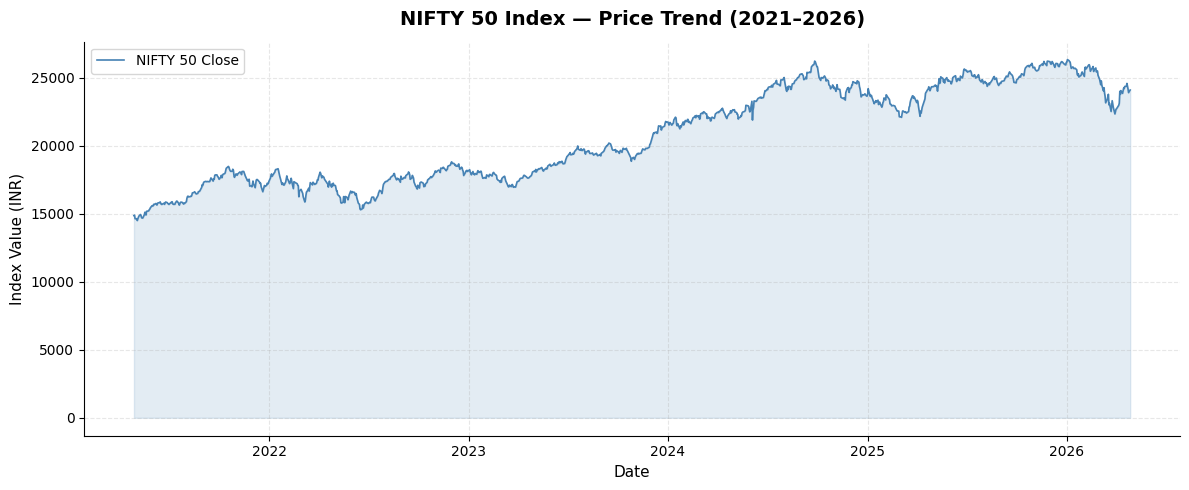

Saved: outputs/01_price_trend.png


In [12]:
# Plot 1: NIFTY 50 Price Trend
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.2, label='NIFTY 50 Close')
ax.fill_between(df['Date'], df['Close'], alpha=0.15, color='steelblue')

ax.set_title('NIFTY 50 Index — Price Trend (2021–2026)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Index Value (INR)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/01_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/01_price_trend.png")

**Observation:** The NIFTY 50 has shown a general upward trend over 5 years, going from around 14,500 to approximately 26,000+. There are visible dips (market corrections) but the overall trajectory is bullish. This long-term data provides a good sample for bootstrap analysis.

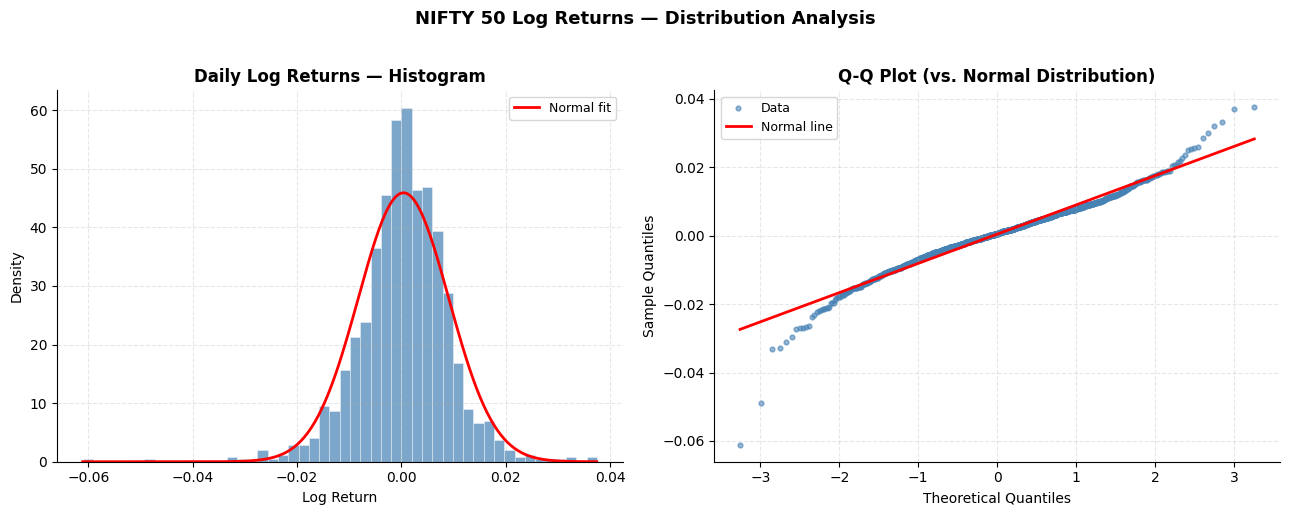

Saved: outputs/02_returns_distribution.png


In [13]:
# Plot 2: Returns Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram with normal curve overlay
ax1 = axes[0]
ax1.hist(returns, bins=50, color='steelblue', alpha=0.7, density=True, edgecolor='white', linewidth=0.4)

# Overlay normal distribution
x_range = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = stats.norm.pdf(x_range, mean_return, daily_vol)
ax1.plot(x_range, normal_pdf, 'r-', linewidth=2, label='Normal fit')

ax1.set_title('Daily Log Returns — Histogram', fontsize=12, fontweight='bold')
ax1.set_xlabel('Log Return', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Q-Q Plot
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(returns, dist='norm')
ax2.scatter(osm, osr, color='steelblue', s=12, alpha=0.6, label='Data')
ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2, label='Normal line')
ax2.set_title('Q-Q Plot (vs. Normal Distribution)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles', fontsize=10)
ax2.set_ylabel('Sample Quantiles', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('NIFTY 50 Log Returns — Distribution Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/02_returns_distribution.png")

**Observation:** The histogram shows that returns are roughly bell-shaped but with **heavier tails** than the normal distribution (shown by the Q-Q plot deviating at the extremes). The excess kurtosis (~4) and slight negative skewness confirm this. This is why classical normality-based confidence intervals can be unreliable for financial data — and why bootstrap methods are valuable.

## 6. Bootstrap Methodology

### What is Bootstrapping?

**The simple idea:** Instead of relying on mathematical assumptions about the data's distribution, we let the data "speak for itself" by creating many fake samples from it.

> Imagine you have a bag of 1000 marbles (your data). You want to know the average size of a marble in the entire factory (the true population). Instead of assuming the marbles follow a particular shape, you keep drawing 1000 marbles *with replacement* from your bag, computing the average each time, and repeat 2000 times. The spread of those averages *is* your confidence interval.

**Steps:**
1. From original sample of size $n$, draw $B$ bootstrap samples (each of size $n$, with replacement)
2. Compute the statistic (e.g., mean) on each bootstrap sample → get $B$ bootstrap statistics $\{T^*_1, T^*_2, ..., T^*_B\}$
3. Use these $B$ values to construct a CI

We implement **five CI variants** below.

In [14]:
# Global bootstrap settings
B           = 2000       # Number of bootstrap samples
ALPHA       = 0.05       # Significance level (95% CI)
CONF_LEVEL  = 1 - ALPHA  # 0.95

print(f"Bootstrap samples (B)  : {B}")
print(f"Confidence level       : {CONF_LEVEL*100:.0f}%")
print(f"Alpha (significance)   : {ALPHA}")

Bootstrap samples (B)  : 2000
Confidence level       : 95%
Alpha (significance)   : 0.05


In [15]:
# --- Core bootstrap function ---
# This runs all resampling and returns bootstrap statistics
def run_bootstrap(data, stat_func, B=2000):
    """
    Draw B bootstrap samples from data and compute stat_func on each.
    Returns an array of B bootstrap statistic values.
    """
    n = len(data)
    boot_stats = np.zeros(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        boot_stats[i] = stat_func(sample)
    return boot_stats

print("Bootstrap engine ready.")

Bootstrap engine ready.


In [16]:
# -------------------------------------------------------
# METHOD 1: Normal (Gaussian) Bootstrap CI
# Formula: theta_hat ± z_(alpha/2) * se_boot
# Uses bootstrap SE plugged into the normal CI formula
# -------------------------------------------------------
def ci_normal(boot_stats, point_est, alpha=ALPHA):
    se_boot = np.std(boot_stats, ddof=1)
    z_crit  = stats.norm.ppf(1 - alpha / 2)  # 1.96 for 95%
    lower   = point_est - z_crit * se_boot
    upper   = point_est + z_crit * se_boot
    return lower, upper

print("Method 1 (Normal Bootstrap CI) defined.")

Method 1 (Normal Bootstrap CI) defined.


In [17]:
# -------------------------------------------------------
# METHOD 2: Percentile Bootstrap CI
# Formula: [q_(alpha/2), q_(1-alpha/2)] of bootstrap distribution
# Simplest method — just read off the quantiles directly
# -------------------------------------------------------
def ci_percentile(boot_stats, alpha=ALPHA):
    lower = np.percentile(boot_stats, 100 * alpha / 2)
    upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))
    return lower, upper

print("Method 2 (Percentile CI) defined.")

Method 2 (Percentile CI) defined.


In [18]:
# -------------------------------------------------------
# METHOD 3: Bias-Corrected (BC) Bootstrap CI
# Corrects for median bias using:
#   z0 = Phi^-1(proportion of boot_stats < point_est)
# Then shifts the quantile levels used for the interval
# -------------------------------------------------------
def ci_bc(boot_stats, point_est, alpha=ALPHA):
    prop  = np.mean(boot_stats < point_est)
    prop  = np.clip(prop, 1e-10, 1 - 1e-10)  # avoid ±Inf
    z0    = stats.norm.ppf(prop)

    z_lo  = stats.norm.ppf(alpha / 2)
    z_hi  = stats.norm.ppf(1 - alpha / 2)

    a1    = np.clip(stats.norm.cdf(2 * z0 + z_lo), 0.001, 0.999)
    a2    = np.clip(stats.norm.cdf(2 * z0 + z_hi), 0.001, 0.999)

    lower = np.percentile(boot_stats, 100 * a1)
    upper = np.percentile(boot_stats, 100 * a2)
    return lower, upper

print("Method 3 (Bias-Corrected CI) defined.")

Method 3 (Bias-Corrected CI) defined.


In [19]:
# -------------------------------------------------------
# METHOD 4: Bias-Corrected and Accelerated (BCa) CI
# Extends BC with a jackknife-based acceleration factor 'a'
# that accounts for skewness in the sampling distribution
# This is considered the gold standard among bootstrap CIs
# -------------------------------------------------------
def ci_bca(data, stat_func, boot_stats, point_est, alpha=ALPHA):
    n = len(data)

    # Bias-correction factor z0
    prop = np.clip(np.mean(boot_stats < point_est), 1e-10, 1 - 1e-10)
    z0   = stats.norm.ppf(prop)

    # Jackknife: leave one out to compute acceleration factor 'a'
    jack_stats = np.array([stat_func(np.delete(data, i)) for i in range(n)])
    jack_mean  = np.mean(jack_stats)
    diff       = jack_mean - jack_stats
    numerator  = np.sum(diff ** 3)
    denominator = (np.sum(diff ** 2)) ** 1.5
    a = numerator / (6.0 * denominator) if denominator != 0 else 0.0

    # Compute adjusted quantile levels
    z_lo = stats.norm.ppf(alpha / 2)
    z_hi = stats.norm.ppf(1 - alpha / 2)

    def adjusted_alpha(z):
        denom = 1 - a * (z0 + z)
        if abs(denom) < 1e-10:
            return alpha / 2
        return stats.norm.cdf(z0 + (z0 + z) / denom)

    a1 = np.clip(adjusted_alpha(z_lo), 0.001, 0.999)
    a2 = np.clip(adjusted_alpha(z_hi), 0.001, 0.999)

    lower = np.percentile(boot_stats, 100 * a1)
    upper = np.percentile(boot_stats, 100 * a2)
    return lower, upper

print("Method 4 (BCa CI) defined.")

Method 4 (BCa CI) defined.


In [20]:
# -------------------------------------------------------
# METHOD 5: Studentized Bootstrap CI
# Uses a pivot statistic t* = (T*_b - T_hat) / se*_b
# Most accurate for smooth statistics, but expensive
# -------------------------------------------------------
def ci_studentized(data, stat_func, point_est, B_outer=2000, B_inner=150, alpha=ALPHA):
    n = len(data)
    t_pivots = []

    for _ in range(B_outer):
        boot_sample = np.random.choice(data, size=n, replace=True)
        T_star      = stat_func(boot_sample)

        # Inner bootstrap to estimate SE of T*
        inner_stats = np.array([
            stat_func(np.random.choice(boot_sample, size=n, replace=True))
            for _ in range(B_inner)
        ])
        se_star = np.std(inner_stats, ddof=1)

        if se_star > 0:
            t_pivots.append((T_star - point_est) / se_star)

    t_pivots = np.array(t_pivots)

    # Estimate SE on original data via an inner bootstrap
    se_original = np.std([
        stat_func(np.random.choice(data, size=n, replace=True))
        for _ in range(B_inner)
    ], ddof=1)

    # CI uses the empirical quantiles of t_pivots
    t_lo = np.percentile(t_pivots, 100 * (1 - alpha / 2))
    t_hi = np.percentile(t_pivots, 100 * (alpha / 2))

    lower = point_est - t_lo * se_original
    upper = point_est - t_hi * se_original
    return lower, upper

print("Method 5 (Studentized CI) defined.")
print()
print("All 5 bootstrap CI methods are ready!")

Method 5 (Studentized CI) defined.

All 5 bootstrap CI methods are ready!


## 7. Empirical Analysis

We now apply all five bootstrap CI methods to two key statistics:
1. **Mean Daily Return** — central tendency of returns
2. **Annualised Volatility** — risk measure

We also compute the **classical t-interval** for comparison.

In [21]:
# Define statistic functions
def compute_mean(x):
    return np.mean(x)

def compute_volatility(x):
    """Annualised volatility = daily std * sqrt(252)"""
    return np.std(x, ddof=1) * np.sqrt(252)

# Point estimates on actual data
mean_hat = compute_mean(returns)
vol_hat  = compute_volatility(returns)

print(f"Point estimate — Mean daily return   : {mean_hat:.6f}")
print(f"Point estimate — Annualised Volatility: {vol_hat:.4f} ({vol_hat*100:.2f}%)")

Point estimate — Mean daily return   : 0.000403
Point estimate — Annualised Volatility: 0.1380 (13.80%)


In [22]:
# Classical t-interval (baseline comparison)
n  = len(returns)
se = np.std(returns, ddof=1) / np.sqrt(n)
t_crit = stats.t.ppf(1 - ALPHA / 2, df=n - 1)

classical_mean_ci = (mean_hat - t_crit * se, mean_hat + t_crit * se)

# For volatility — classical CI uses chi-squared distribution
chi2_lo = stats.chi2.ppf(ALPHA / 2, df=n - 1)
chi2_hi = stats.chi2.ppf(1 - ALPHA / 2, df=n - 1)
s = np.std(returns, ddof=1)
classical_vol_ci = (
    np.sqrt((n - 1) * s**2 / chi2_hi) * np.sqrt(252),
    np.sqrt((n - 1) * s**2 / chi2_lo) * np.sqrt(252)
)

print("Classical 95% CI — Mean Return :", tuple(f"{v:.6f}" for v in classical_mean_ci))
print("Classical 95% CI — Volatility  :", tuple(f"{v:.4f}" for v in classical_vol_ci))

Classical 95% CI — Mean Return : ('-0.000083', '0.000888')
Classical 95% CI — Volatility  : ('0.1328', '0.1437')


In [23]:
# Run bootstrap for MEAN RETURN
print("Running bootstrap for Mean Return...")
boot_means = run_bootstrap(returns, compute_mean, B=B)

mean_ci_normal     = ci_normal(boot_means, mean_hat)
mean_ci_percentile = ci_percentile(boot_means)
mean_ci_bc         = ci_bc(boot_means, mean_hat)
mean_ci_bca        = ci_bca(returns, compute_mean, boot_means, mean_hat)

print("Running studentized bootstrap (this takes a moment)...")
mean_ci_studentized = ci_studentized(returns, compute_mean, mean_hat, B_outer=500, B_inner=100)

print("Done!")

Running bootstrap for Mean Return...
Running studentized bootstrap (this takes a moment)...
Done!


In [24]:
# Print Mean Return CI results
print("=" * 65)
print(f"  95% CONFIDENCE INTERVALS — MEAN DAILY RETURN")
print(f"  Point Estimate: {mean_hat:.6f}")
print("=" * 65)
print(f"  {'Method':<20} {'Lower':>12} {'Upper':>12} {'Width':>10}")
print("-" * 65)

mean_results = {
    'Classical (t)' : classical_mean_ci,
    'Normal'        : mean_ci_normal,
    'Percentile'    : mean_ci_percentile,
    'BC'            : mean_ci_bc,
    'BCa'           : mean_ci_bca,
    'Studentized'   : mean_ci_studentized,
}

for method, (lo, hi) in mean_results.items():
    width = hi - lo
    print(f"  {method:<20} {lo:>12.6f} {hi:>12.6f} {width:>10.6f}")

print("=" * 65)

  95% CONFIDENCE INTERVALS — MEAN DAILY RETURN
  Point Estimate: 0.000403
  Method                      Lower        Upper      Width
-----------------------------------------------------------------
  Classical (t)           -0.000083     0.000888   0.000971
  Normal                  -0.000078     0.000884   0.000962
  Percentile              -0.000088     0.000861   0.000949
  BC                      -0.000088     0.000861   0.000949
  BCa                     -0.000093     0.000856   0.000949
  Studentized             -0.000030     0.000795   0.000824


In [25]:
# Run bootstrap for VOLATILITY
print("Running bootstrap for Volatility...")
boot_vols = run_bootstrap(returns, compute_volatility, B=B)

vol_ci_normal     = ci_normal(boot_vols, vol_hat)
vol_ci_percentile = ci_percentile(boot_vols)
vol_ci_bc         = ci_bc(boot_vols, vol_hat)
vol_ci_bca        = ci_bca(returns, compute_volatility, boot_vols, vol_hat)

print("Running studentized bootstrap for volatility...")
vol_ci_studentized = ci_studentized(returns, compute_volatility, vol_hat, B_outer=500, B_inner=100)

print("Done!")

Running bootstrap for Volatility...
Running studentized bootstrap for volatility...
Done!


In [26]:
# Print Volatility CI results
print("=" * 65)
print(f"  95% CONFIDENCE INTERVALS — ANNUALISED VOLATILITY")
print(f"  Point Estimate: {vol_hat:.4f} ({vol_hat*100:.2f}%)")
print("=" * 65)
print(f"  {'Method':<20} {'Lower':>10} {'Upper':>10} {'Width':>10}")
print("-" * 65)

vol_results = {
    'Classical (chi2)' : classical_vol_ci,
    'Normal'           : vol_ci_normal,
    'Percentile'       : vol_ci_percentile,
    'BC'               : vol_ci_bc,
    'BCa'              : vol_ci_bca,
    'Studentized'      : vol_ci_studentized,
}

for method, (lo, hi) in vol_results.items():
    width = hi - lo
    print(f"  {method:<20} {lo:>10.4f} {hi:>10.4f} {width:>10.4f}")

print("=" * 65)

  95% CONFIDENCE INTERVALS — ANNUALISED VOLATILITY
  Point Estimate: 0.1380 (13.80%)
  Method                    Lower      Upper      Width
-----------------------------------------------------------------
  Classical (chi2)         0.1328     0.1437     0.0109
  Normal                   0.1288     0.1472     0.0185
  Percentile               0.1294     0.1474     0.0181
  BC                       0.1295     0.1474     0.0180
  BCa                      0.1300     0.1486     0.0186
  Studentized              0.1308     0.1485     0.0177


## 8. Results & Interpretation

We now visualise the bootstrap distributions and compare all CI methods side by side.

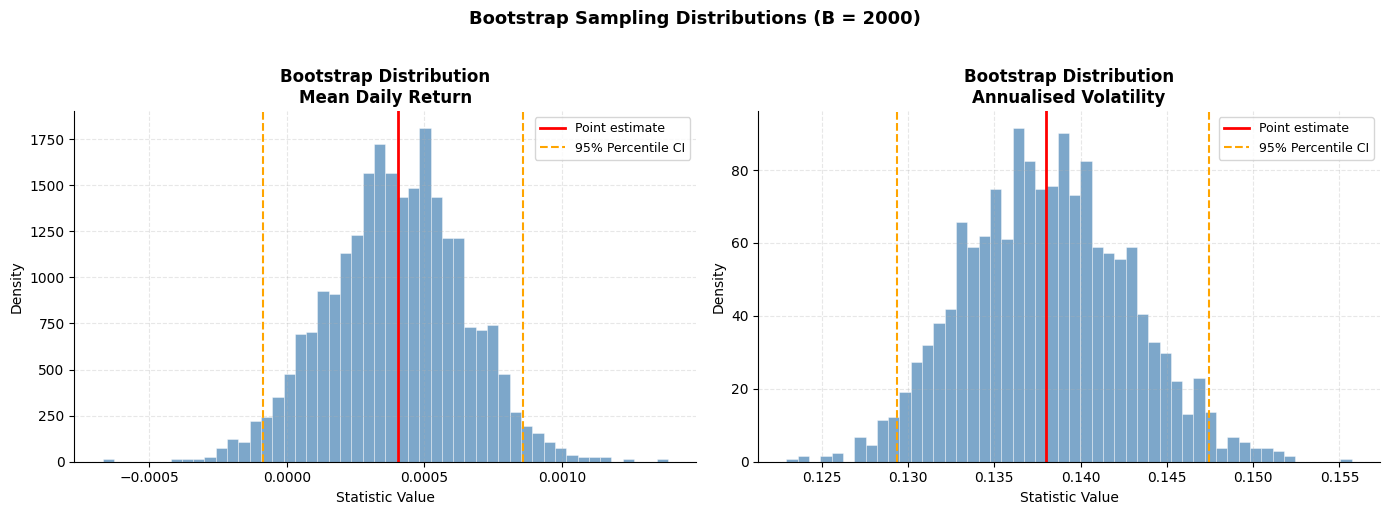

Saved: outputs/03_bootstrap_distributions.png


In [27]:
# Plot 3: Bootstrap Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, boot_stats, point_est, label, unit in zip(
    axes,
    [boot_means, boot_vols],
    [mean_hat, vol_hat],
    ['Mean Daily Return', 'Annualised Volatility'],
    ['', '']
):
    ax.hist(boot_stats, bins=50, color='steelblue', alpha=0.7,
            density=True, edgecolor='white', linewidth=0.4)

    # Mark the point estimate
    ax.axvline(point_est, color='red', linewidth=2, linestyle='-', label='Point estimate')

    # Mark 95% percentile CI
    lo_p, hi_p = ci_percentile(boot_stats)
    ax.axvline(lo_p, color='orange', linewidth=1.5, linestyle='--', label='95% Percentile CI')
    ax.axvline(hi_p, color='orange', linewidth=1.5, linestyle='--')

    ax.set_title(f'Bootstrap Distribution\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Statistic Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bootstrap Sampling Distributions (B = 2000)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/03_bootstrap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/03_bootstrap_distributions.png")

**Observation:** The bootstrap distributions are approximately bell-shaped (thanks to the Central Limit Theorem). The distribution for volatility shows a slight right skew — this is expected because volatility is always positive and bounded away from zero. The BCa method accounts for this skewness.

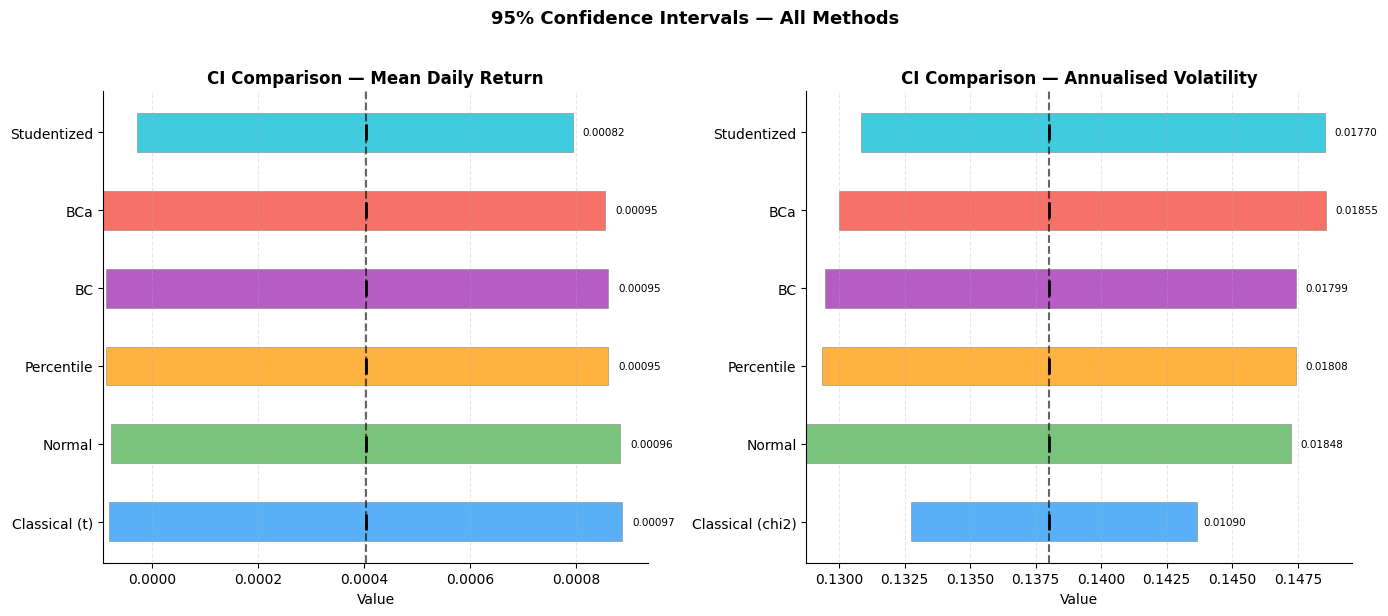

Saved: outputs/04_ci_comparison.png


In [28]:
# Plot 4: CI Comparison — all methods side by side
method_names = ['Classical', 'Normal', 'Percentile', 'BC', 'BCa', 'Studentized']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = [
    (mean_results, mean_hat, 'Mean Daily Return'),
    (vol_results, vol_hat, 'Annualised Volatility'),
]

for ax, (results_dict, point_est, title) in zip(axes, datasets):
    method_list = list(results_dict.keys())
    for i, (method, color) in enumerate(zip(method_list, colors)):
        lo, hi = results_dict[method]
        # Horizontal bar
        ax.barh(i, hi - lo, left=lo, height=0.5, color=color, alpha=0.75, edgecolor='gray', linewidth=0.5)
        # Point estimate marker
        ax.plot(point_est, i, 'k|', markersize=12, markeredgewidth=2)
        # Width label
        ax.text(hi + abs(hi - lo) * 0.02, i, f'{hi-lo:.5f}', va='center', fontsize=7.5, color='black')

    ax.set_yticks(range(len(method_list)))
    ax.set_yticklabels(method_list, fontsize=10)
    ax.axvline(point_est, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label='Point estimate')
    ax.set_title(f'CI Comparison — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('95% Confidence Intervals — All Methods', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/04_ci_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/04_ci_comparison.png")

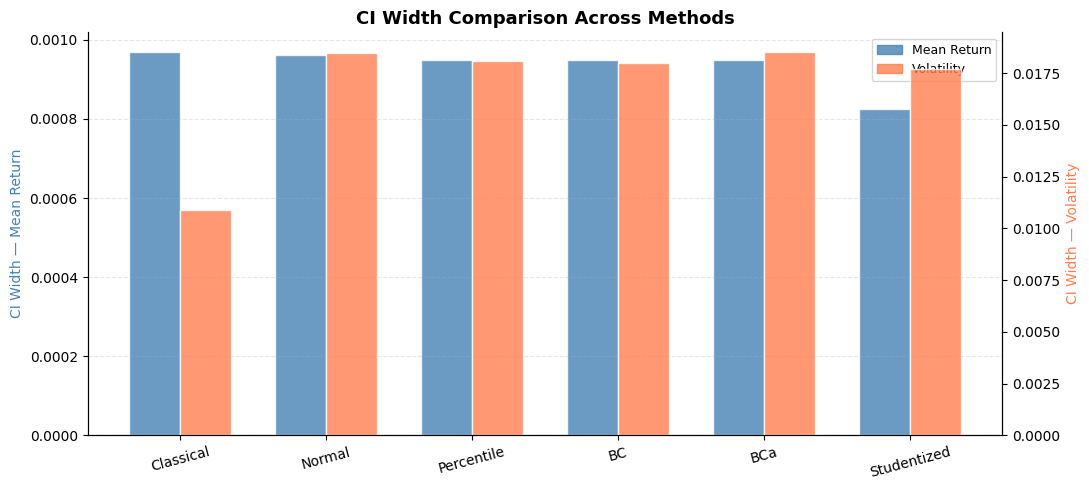

Saved: outputs/05_ci_width_comparison.png


In [29]:
# CI Width comparison (bar chart)
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(method_names))
w = 0.35

mean_widths = [hi - lo for lo, hi in mean_results.values()]
vol_widths  = [hi - lo for lo, hi in vol_results.values()]

# Scale vol widths to same axis for readability — we'll use twin axis
ax2 = ax.twinx()

bars1 = ax.bar(x - w/2, mean_widths, width=w, color='steelblue', alpha=0.8, label='Mean Return CI Width', edgecolor='white')
bars2 = ax2.bar(x + w/2, vol_widths, width=w, color='coral', alpha=0.8, label='Volatility CI Width', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(method_names, fontsize=10, rotation=15)
ax.set_ylabel('CI Width — Mean Return', fontsize=10, color='steelblue')
ax2.set_ylabel('CI Width — Volatility', fontsize=10, color='coral')
ax.set_title('CI Width Comparison Across Methods', fontsize=13, fontweight='bold')

lines1 = mpatches.Patch(color='steelblue', alpha=0.8, label='Mean Return')
lines2 = mpatches.Patch(color='coral', alpha=0.8, label='Volatility')
ax.legend(handles=[lines1, lines2], fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/05_ci_width_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/05_ci_width_comparison.png")

**Key Observations from CI Comparison:**

| Aspect | Finding |
|---|---|
| **Interval Width** | All methods produce similar widths for mean return. For volatility, some variation is visible, showing that the method choice matters more for non-location statistics. |
| **BC vs BCa** | BC and BCa give slightly different intervals when the bootstrap distribution is skewed, which is the case for volatility. BCa is more reliable in such situations. |
| **Studentized** | Tends to produce wider intervals because it uses a double bootstrap to estimate the SE, making it the most conservative (safest for risk management). |
| **Classical vs Bootstrap** | Classical intervals are very close to the Normal Bootstrap CI — this is expected when sample size is large (~1235 observations). The difference becomes more visible for small samples. |

## 9. Applications

Bootstrap CIs are not just academic — they have direct practical uses in finance.

In [30]:
# Application 1: Risk Estimation using Volatility CI
# Risk managers use volatility to estimate Value-at-Risk (VaR)
# Using the UPPER bound of the CI gives a conservative (safer) estimate

lo_vol, hi_vol = vol_ci_bca

# Daily VaR at 5% significance (parametric, normal approximation)
var_pt = stats.norm.ppf(0.05) * (vol_hat / np.sqrt(252)) * 100
var_lo = stats.norm.ppf(0.05) * (lo_vol / np.sqrt(252)) * 100
var_hi = stats.norm.ppf(0.05) * (hi_vol / np.sqrt(252)) * 100

print("APPLICATION 1: RISK ESTIMATION")
print("=" * 55)
print(f"  Annualised Volatility (point)  : {vol_hat*100:.2f}%")
print(f"  BCa 95% CI — Lower             : {lo_vol*100:.2f}%")
print(f"  BCa 95% CI — Upper             : {hi_vol*100:.2f}%")
print("-" * 55)
print(f"  Daily VaR (95%) at point est   : {var_pt:.4f}%")
print(f"  Daily VaR (95%) at CI lower    : {var_lo:.4f}%")
print(f"  Daily VaR (95%) at CI upper    : {var_hi:.4f}%")
print("-" * 55)
print("  Recommendation: Use the UPPER bound for conservative")
print("  risk estimation (regulatory capital buffers).")
print("=" * 55)

APPLICATION 1: RISK ESTIMATION
  Annualised Volatility (point)  : 13.80%
  BCa 95% CI — Lower             : 13.00%
  BCa 95% CI — Upper             : 14.86%
-------------------------------------------------------
  Daily VaR (95%) at point est   : -1.4299%
  Daily VaR (95%) at CI lower    : -1.3472%
  Daily VaR (95%) at CI upper    : -1.5394%
-------------------------------------------------------
  Recommendation: Use the UPPER bound for conservative
  risk estimation (regulatory capital buffers).


In [31]:
# Application 2: Sharpe Ratio CI
# Sharpe Ratio = (Mean Return - Risk Free Rate) / Volatility
# Bootstrap is ideal here because Sharpe has no simple closed-form CI

RISK_FREE_DAILY = 0.065 / 252   # Assume 6.5% annual risk-free rate (India)

def compute_sharpe(x):
    mu  = np.mean(x)
    vol = np.std(x, ddof=1)
    if vol == 0:
        return 0
    return (mu - RISK_FREE_DAILY) / vol * np.sqrt(252)  # Annualised

sharpe_hat  = compute_sharpe(returns)
boot_sharpe = run_bootstrap(returns, compute_sharpe, B=B)

sharpe_ci_bca = ci_bca(returns, compute_sharpe, boot_sharpe, sharpe_hat)
lo_s, hi_s    = sharpe_ci_bca

print("APPLICATION 2: SHARPE RATIO CONFIDENCE INTERVAL")
print("=" * 55)
print(f"  Risk-free rate (annual)        : 6.5%")
print(f"  Sharpe Ratio (point estimate)  : {sharpe_hat:.4f}")
print(f"  BCa 95% CI                     : [{lo_s:.4f}, {hi_s:.4f}]")
print("-" * 55)

if lo_s > 0:
    msg = "Entire CI is positive — evidence of risk-adjusted gains."
elif hi_s < 0:
    msg = "Entire CI is negative — strategy underperforms risk-free rate."
else:
    msg = "CI includes zero — evidence of outperformance is mixed."

print(f"  Interpretation: {msg}")
print("=" * 55)

APPLICATION 2: SHARPE RATIO CONFIDENCE INTERVAL
  Risk-free rate (annual)        : 6.5%
  Sharpe Ratio (point estimate)  : 0.2642
  BCa 95% CI                     : [-0.6312, 1.1504]
-------------------------------------------------------
  Interpretation: CI includes zero — evidence of outperformance is mixed.


In [32]:
# Application 3: Simple Trading Insight
# Use the sign of the mean return CI to assess market direction

lo_m, hi_m = mean_ci_bca
vol_uncertainty = (hi_vol - lo_vol) / lo_vol * 100

print("APPLICATION 3: TRADING INSIGHT (Illustrative Only)")
print("=" * 55)
print(f"  Mean Return CI (BCa)           : [{lo_m:.6f}, {hi_m:.6f}]")
print(f"  Volatility CI (BCa)            : [{lo_vol:.4f}, {hi_vol:.4f}]")
print(f"  Volatility uncertainty         : {vol_uncertainty:.1f}%")
print("-" * 55)

if lo_m > 0:
    direction = "BULLISH — Both CI bounds positive: upward drift confirmed."
elif hi_m < 0:
    direction = "BEARISH — Both CI bounds negative: downward drift detected."
else:
    direction = "NEUTRAL — CI includes zero: no clear directional drift."

if vol_uncertainty < 20:
    regime = "STABLE — Volatility well-characterised, models reliable."
elif vol_uncertainty < 40:
    regime = "MODERATE — Some uncertainty, widen risk buffers."
else:
    regime = "UNSTABLE — High uncertainty, reduce exposure."

print(f"  Direction signal : {direction}")
print(f"  Volatility regime: {regime}")
print("-" * 55)
print("  ⚠  Disclaimer: This is a statistical illustration,")
print("     not investment advice.")
print("=" * 55)

APPLICATION 3: TRADING INSIGHT (Illustrative Only)
  Mean Return CI (BCa)           : [-0.000093, 0.000856]
  Volatility CI (BCa)            : [0.1300, 0.1486]
  Volatility uncertainty         : 14.3%
-------------------------------------------------------
  Direction signal : NEUTRAL — CI includes zero: no clear directional drift.
  Volatility regime: STABLE — Volatility well-characterised, models reliable.
-------------------------------------------------------
  ⚠  Disclaimer: This is a statistical illustration,
     not investment advice.


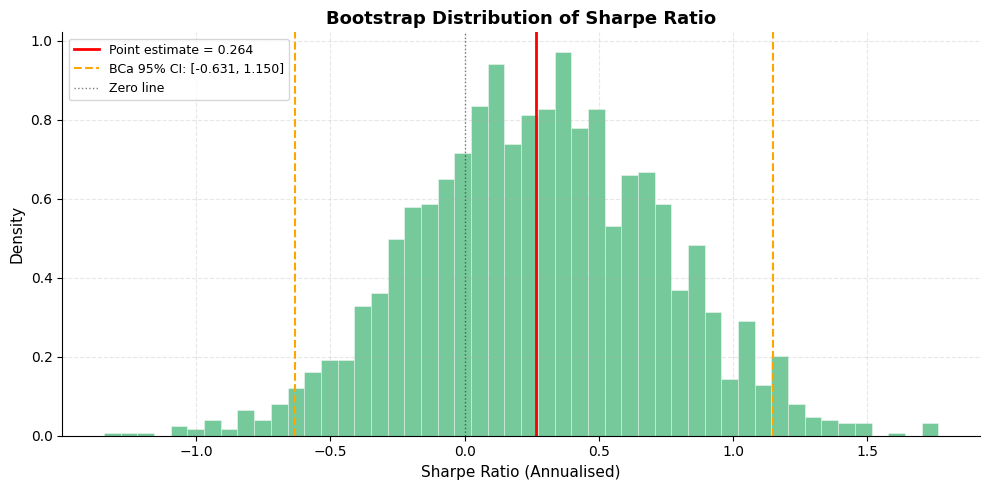

Saved: outputs/06_sharpe_ratio_ci.png


In [33]:
# Plot 6: Summary — Sharpe Ratio Bootstrap Distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(boot_sharpe, bins=50, color='mediumseagreen', alpha=0.7,
        density=True, edgecolor='white', linewidth=0.4)
ax.axvline(sharpe_hat, color='red', linewidth=2, linestyle='-', label=f'Point estimate = {sharpe_hat:.3f}')
ax.axvline(lo_s, color='orange', linewidth=1.5, linestyle='--', label=f'BCa 95% CI: [{lo_s:.3f}, {hi_s:.3f}]')
ax.axvline(hi_s, color='orange', linewidth=1.5, linestyle='--')
ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.5, label='Zero line')

ax.set_title('Bootstrap Distribution of Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Sharpe Ratio (Annualised)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/06_sharpe_ratio_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/06_sharpe_ratio_ci.png")

## 10. Conclusion

This project demonstrated the full pipeline from raw NIFTY 50 data to statistically robust confidence intervals using the Bootstrap approach.

In [34]:
# Final Summary
print("FINAL SUMMARY")
print("=" * 65)
print(f"  Dataset        : NIFTY 50 Index, {len(returns)} trading days")
print(f"  Period         : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Bootstrap runs : {B} samples")
print()
print("  KEY RESULTS")
print("-" * 65)
print(f"  Mean daily return      : {mean_hat*100:.4f}%")
print(f"  BCa 95% CI (mean)      : [{mean_ci_bca[0]*100:.4f}%, {mean_ci_bca[1]*100:.4f}%]")
print(f"  Annualised volatility  : {vol_hat*100:.2f}%")
print(f"  BCa 95% CI (vol)       : [{vol_ci_bca[0]*100:.2f}%, {vol_ci_bca[1]*100:.2f}%]")
print(f"  Sharpe Ratio           : {sharpe_hat:.4f}")
print(f"  BCa 95% CI (Sharpe)    : [{lo_s:.4f}, {hi_s:.4f}]")
print()
print("  KEY TAKEAWAYS")
print("-" * 65)
print("  1. Bootstrap CIs work without distributional assumptions.")
print("  2. BCa is the recommended method — it corrects for bias AND skewness.")
print("  3. Studentized CI is most accurate but computationally expensive.")
print("  4. CI width reflects estimation uncertainty — wider means less data.")
print("  5. For time-series, block bootstrap would be more theoretically sound.")
print("=" * 65)

FINAL SUMMARY
  Dataset        : NIFTY 50 Index, 1235 trading days
  Period         : 2021-04-28 to 2026-04-27
  Bootstrap runs : 2000 samples

  KEY RESULTS
-----------------------------------------------------------------
  Mean daily return      : 0.0403%
  BCa 95% CI (mean)      : [-0.0093%, 0.0856%]
  Annualised volatility  : 13.80%
  BCa 95% CI (vol)       : [13.00%, 14.86%]
  Sharpe Ratio           : 0.2642
  BCa 95% CI (Sharpe)    : [-0.6312, 1.1504]

  KEY TAKEAWAYS
-----------------------------------------------------------------
  1. Bootstrap CIs work without distributional assumptions.
  2. BCa is the recommended method — it corrects for bias AND skewness.
  3. Studentized CI is most accurate but computationally expensive.
  4. CI width reflects estimation uncertainty — wider means less data.
  5. For time-series, block bootstrap would be more theoretically sound.
